In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath("..")  
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import folium
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from skgstat import Variogram
import geopandas as gpd
from shapely.geometry import Point
import statsmodels.api as sm
import ast
from shapely.ops import unary_union
from pykrige.uk import UniversalKriging
from esda import G_Local
import matplotlib.pyplot as plt
from libpysal.weights import Kernel




<Axes: >

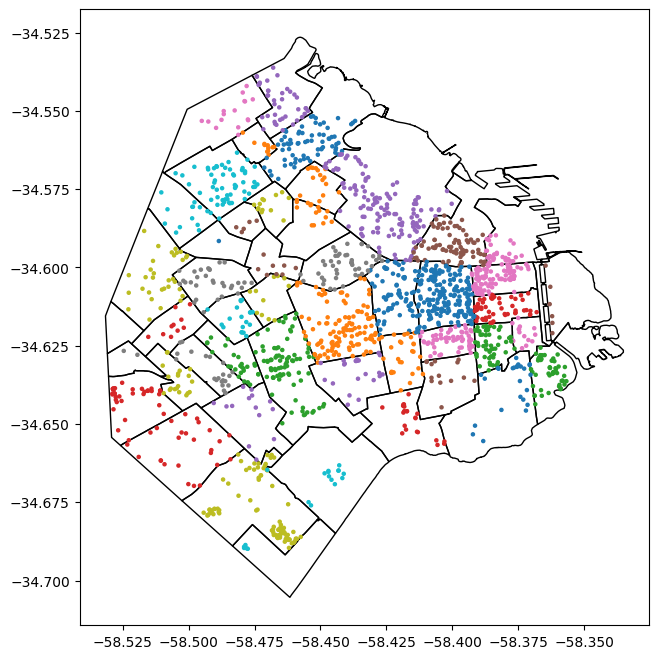

In [2]:
df = pd.read_csv("../storage/data/arg_venta_data.csv")

#Muchas veces publican al mismo departamento varias veces con distintos IDS, por eso se eliminan registros duplicados en una misma ubicación
#Podrían perderse algunos datos en un mismo edificio, pero se gana en calidad de datos
df = df.drop_duplicates(subset=["longitud", "latitud"], keep="first")

# Barrios
barrios = gpd.read_file("../barrios.geojson")


caba_polygon = unary_union(barrios.geometry)


# Puntos
gdf_puntos = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitud, df.latitud),
    crs="EPSG:4326"
)

# Unificar CRS
barrios = barrios.to_crs(gdf_puntos.crs)
gdf = gpd.sjoin(
    gdf_puntos,
    barrios,
    how="left",
    predicate="within"
)


gdf_deptos = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitud, df.latitud),
    crs="EPSG:4326"
)

gdf = gpd.sjoin(
    gdf_deptos,
    barrios[['nombre', 'comuna', 'geometry']],
    how='left',
    predicate='within'
)
gdf= gdf.rename(columns={"nombre": "barrio"})

fig, ax = plt.subplots(figsize=(8, 8))
barrios.plot(ax=ax, edgecolor="black", facecolor="none")

gdf.plot(
    ax=ax,
    column='barrio',
    markersize=5,
    legend=False
)




In [3]:
# ─────────────────────────────
# 1. Filtrar barrios con >= 5 obs
# ─────────────────────────────
gdf = gdf[
    gdf.groupby('barrio')['barrio'].transform('size') >= 5
]

# ─────────────────────────────
# 2. Filtros de validez
# ─────────────────────────────
gdf = gdf[gdf['valido_hasta'].isna()]
gdf = gdf[gdf['precio'].notna()]
gdf = gdf[gdf['area_m2_total'].notna()]
gdf = gdf[gdf['ambientes'].notna()]

# ─────────────────────────────
# 3. Imputaciones simples
# ─────────────────────────────
gdf['expensas'] = gdf['expensas'].fillna(0)
gdf['banos'] = gdf['banos'].fillna(1)
gdf['cocheras'] = gdf['cocheras'].fillna(0)
gdf['area_m2_descubierta'] = gdf['area_m2_descubierta'].fillna(0)
# ─────────────────────────────
# 4. Antigüedad: media por barrio
# ─────────────────────────────
gdf['antiguedad'] = gdf['antiguedad'].fillna(
    gdf.groupby('barrio')['antiguedad'].transform('mean')
)
#En caso de que quede alguno con NA por que en un barrio hay solo un dato y este dato es NA
gdf['antiguedad'] = gdf['antiguedad'].fillna(gdf['antiguedad'].mode().iloc[0])
# ─────────────────────────────
# 5. Estado: valor más frecuente por (barrio, antiguedad)
# ─────────────────────────────
gdf['antiguedad_cat'] = gdf['antiguedad'].round().astype('Int64')

estado_moda = (
    gdf
    .dropna(subset=['estado'])
    .groupby(['barrio', 'antiguedad_cat'])['estado']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
)

# Imputar solo donde falta
mask = gdf['estado'].isna()

gdf.loc[mask, 'estado'] = (
    gdf.loc[mask]
    .set_index(['barrio', 'antiguedad_cat'])
    .index
    .map(estado_moda)
)
# hay un solo dato con ese año de antiguedad
gdf['estado'] = gdf['estado'].fillna(gdf['estado'].mode().iloc[0])

# Y ahora lo transformamos int 
orden_estado = {
    'Excelente': 5,
    "Muy Bueno": 4,
    'Bueno': 3,
    'Regular': 2,
    'A Refaccionar': 1
}
gdf["estado_num"] = gdf["estado"].map(orden_estado)


In [4]:
df_dolar = pd.read_csv("../storage/data/dolar_hoy.csv")

dolar_oficial_venta = (
    df_dolar.loc[df_dolar['tipo_dolar'] == 'oficial', 'valor']
    .iloc[0]
)


mask_usd = gdf['moneda'] == "ARS"

gdf.loc[mask_usd, 'precio'] = (
    gdf.loc[mask_usd, 'precio'] / dolar_oficial_venta
)


# añadimos el log del precio 
gdf['log_precio'] = np.log(gdf['precio'])



In [5]:
gdf = gdf.reset_index(drop=True)


## Hipótesis

El precio de una propiedad depende de su superficie (en m²) y de la cantidad de ambientes. Sin embargo, se plantea la hipótesis de que **la relación entre estas variables y el precio no es espacialmente homogénea**, es decir, que los efectos marginales de la superficie y de los ambientes **varían según la ubicación geográfica**.

Por ejemplo, al comparar dos departamentos con la misma superficie y cantidad de ambientes, el incremento en el precio asociado a agregar un ambiente adicional podría ser mayor en barrios como Palermo que en otros como Caballito. Esto sugiere la existencia de **dependencia espacial en los coeficientes subyacentes del modelo**, más allá de diferencias en los niveles absolutos de precios.

---

## Análisis

Para explorar esta hipótesis, se analiza la relación entre el precio (en USD) y la superficie (en m²), estratificando por cantidad de ambientes y considerando distintos barrios de la ciudad.

Si las pendientes de estas relaciones —es decir, el efecto marginal de la superficie o de los ambientes sobre el precio— difieren sistemáticamente entre barrios, ello constituye evidencia de **heterogeneidad espacial en la relación precio–atributos**, incompatible con modelos globales de coeficientes constantes.

---

## Conclusión

Los resultados sugieren que la relación entre el precio por metro cuadrado y la cantidad de ambientes presenta una estructura espacial clara. En particular, los efectos marginales asociados a los atributos de la propiedad varían entre distintos barrios, indicando que **la relación subyacente no es uniforme en el espacio**.

Esta evidencia respalda el uso de **modelos espaciales con coeficientes locales**, como la Regresión Geográficamente Ponderada (GWR), que permiten capturar adecuadamente la heterogeneidad espacial presente en el mercado inmobiliario.


In [6]:
densidad_naive = (
    gdf
    .groupby('barrio')
    .size()
    .sort_values(ascending=False)
)

densidad_naive.head()


barrio
Balvanera      180
Palermo        122
Caballito      111
San Nicolas     96
Recoleta        81
dtype: int64

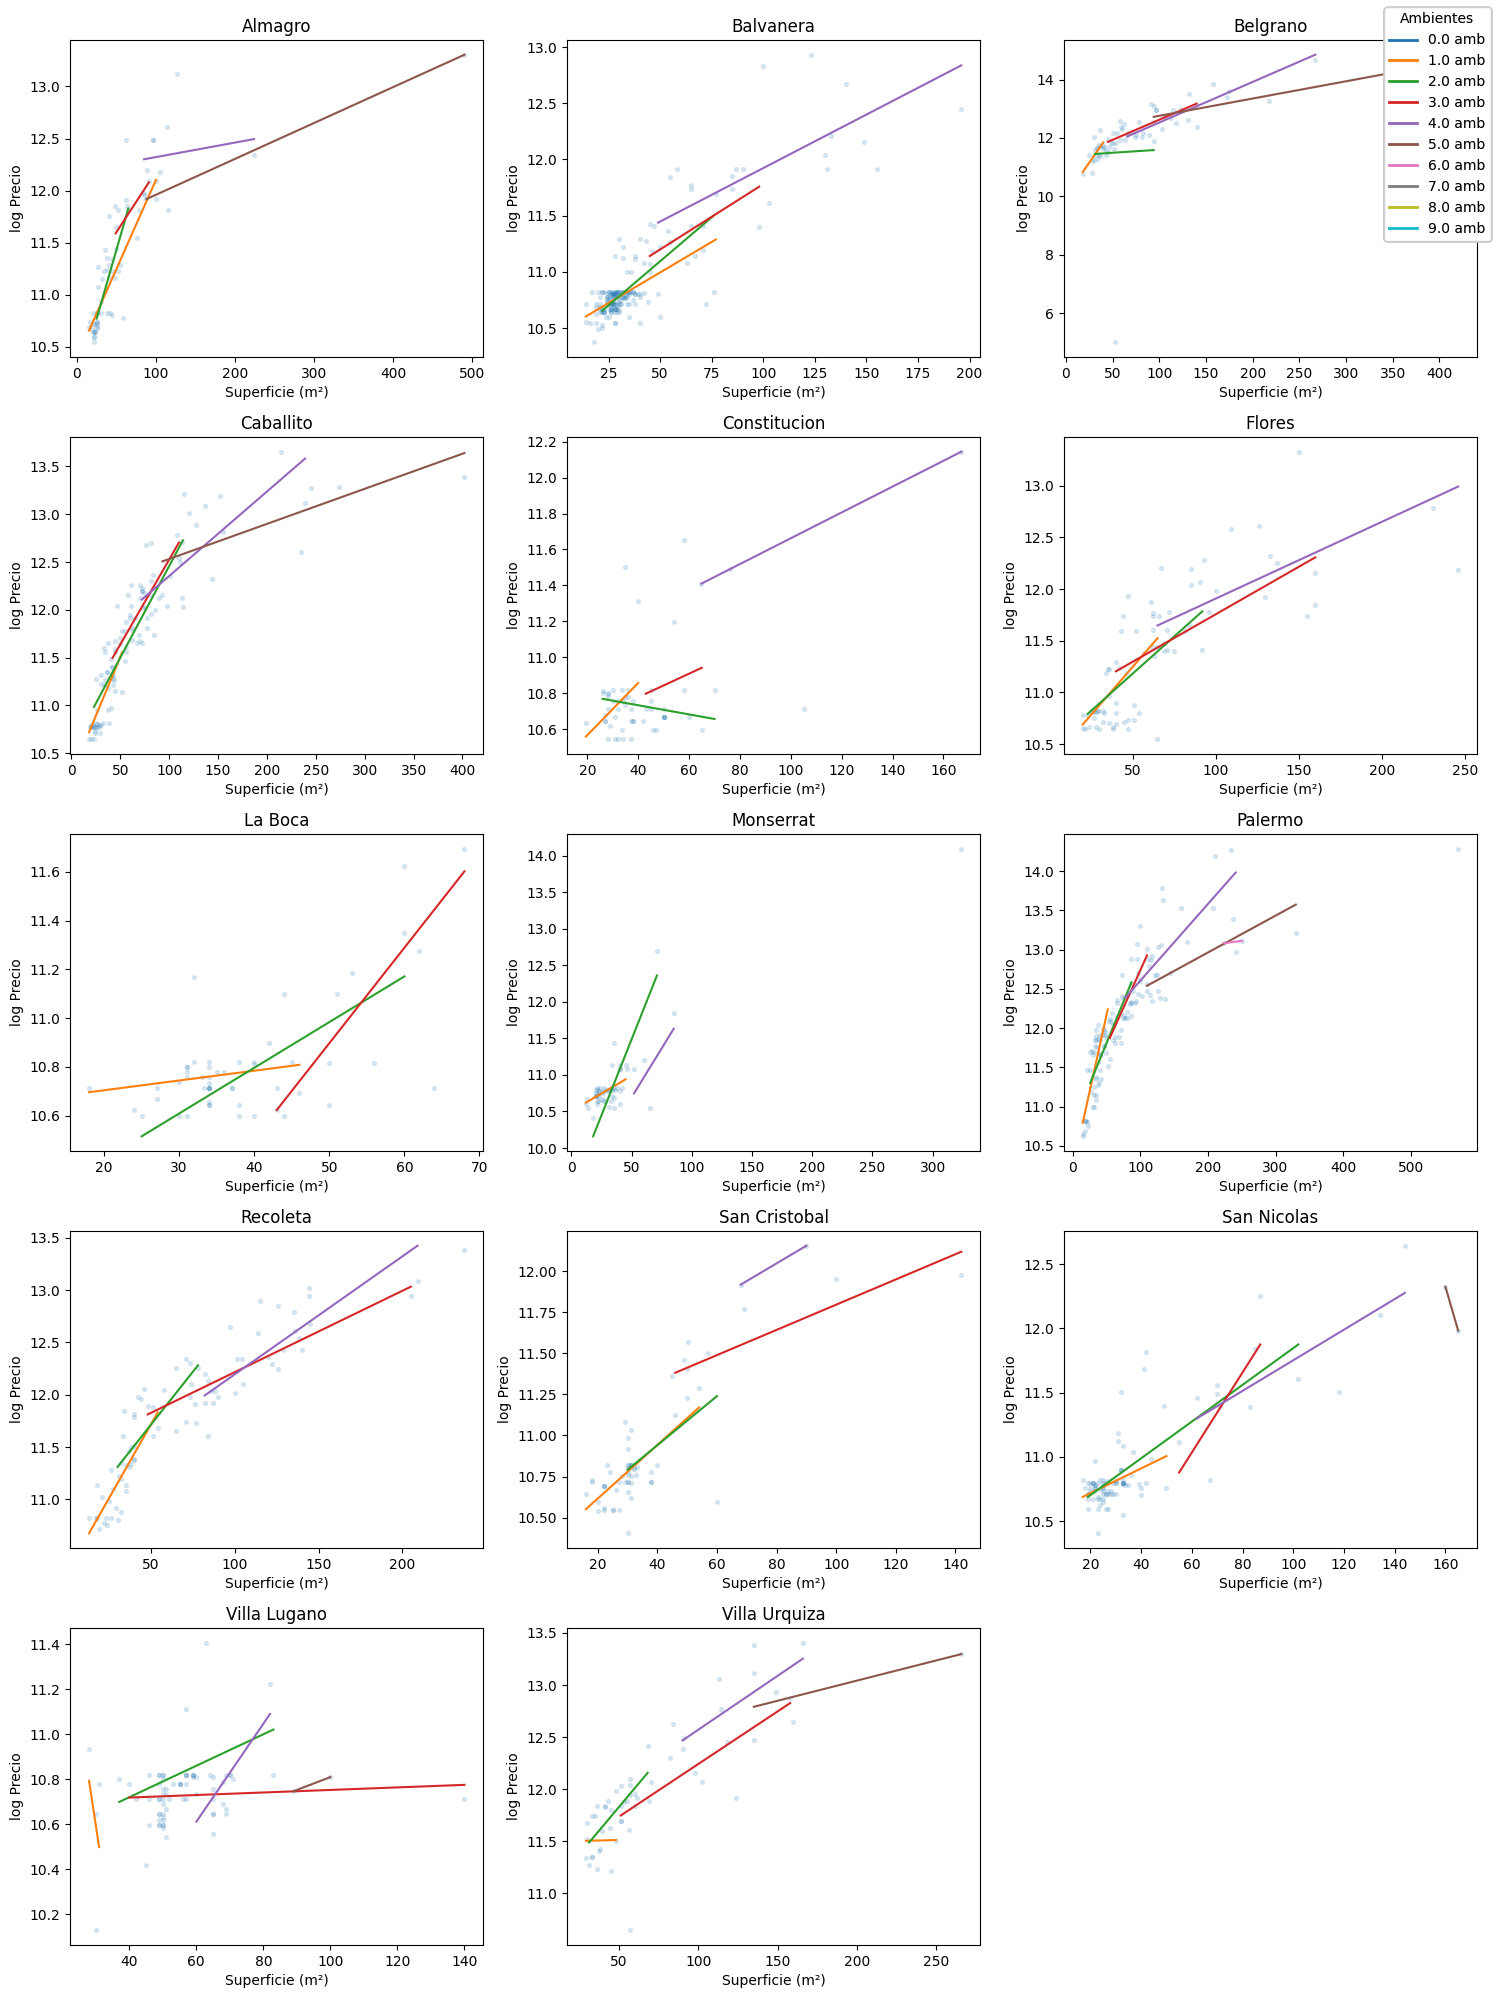

In [7]:
min_obs = 50

barrios_con_observaciones = (
    gdf
    .groupby('barrio')
    .size()
    .loc[lambda s: s >= min_obs]
    .index
    .tolist()
)

n = len(barrios_con_observaciones)
ncols = 3
nrows = int(np.ceil(n / ncols))

import matplotlib.cm as cm
from matplotlib.lines import Line2D

ambientes = sorted(gdf['ambientes'].unique())
cmap = cm.get_cmap("tab10")

color_por_amb = {
    amb: cmap(i % cmap.N)
    for i, amb in enumerate(ambientes)
}

# Límites globales
xmin = gdf['area_m2_total'].min()
xmax = 400

ymin = gdf['log_precio'].min()
ymax = 2*1e6


fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for ax, barrio in zip(axes, barrios_con_observaciones):

    gdf_b = gdf[gdf['barrio'] == barrio]

    # ---- densidad de puntos ----
    ax.scatter(
        gdf_b['area_m2_total'],
        gdf_b['log_precio'],
        s=8,
        alpha=0.15
    )

    for amb in sorted(gdf_b['ambientes'].unique()):
        sub = gdf_b[gdf_b['ambientes'] == amb]

        X = sm.add_constant(sub['area_m2_total'])
        y = sub['log_precio']

        model = sm.OLS(y, X).fit()

        x_grid = np.linspace(
            sub['area_m2_total'].min(),
            sub['area_m2_total'].max(),
            100
        )

        y_hat = model.predict(
            sm.add_constant(x_grid)
        )

        ax.plot(
            x_grid,
            y_hat,
            color=color_por_amb[amb],
            label=f'{amb} amb'
        )



    ax.set_title(barrio)
    ax.set_xlabel('Superficie (m²)')
    ax.set_ylabel('log Precio')

    legend_elements = [
        Line2D(
            [0], [0],
            color=color_por_amb[amb],
            lw=2,
            label=f'{amb} amb'
        )
        for amb in ambientes
    ]

    fig.legend(
        handles=legend_elements,
        loc='upper right',
        title='Ambientes'
    )

for ax in axes[len(barrios_con_observaciones):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


## Análisis exploratorio espacial del precio por m²

Se calcula el precio por metro cuadrado de cada propiedad, considerando la superficie total (incluyendo superficie descubierta), y se aplica kriging con el objetivo de obtener una superficie espacial suave que permita visualizar, de forma exploratoria, la estructura espacial del precio en la ciudad.

El mapa resultante muestra que los valores más elevados del precio por metro cuadrado se concentran en la franja costera de la ciudad de Buenos Aires, destacándose particularmente el área de Puerto Madero. Asimismo, se observa un gradiente espacial claro, con una tendencia creciente de los precios desde el sur hacia el norte de la ciudad.

Este patrón sugiere que el precio por metro cuadrado no se distribuye de manera aleatoria en el espacio, sino que presenta dependencia espacial y posibles cambios estructurales según la localización. En este sentido, el kriging cumple un rol descriptivo clave al revelar regularidades espaciales que motivan el uso posterior de modelos espaciales más sofisticados, capaces de capturar heterogeneidad y no estacionariedad en las relaciones subyacentes.


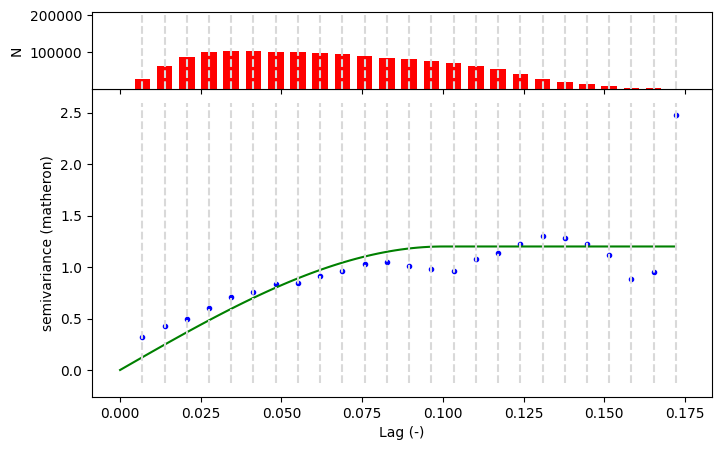

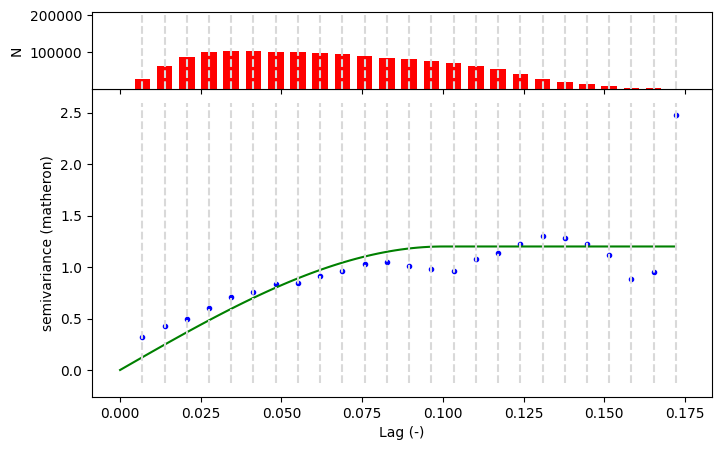

In [8]:

barrios = gpd.read_file("../barrios.geojson")
barrios = barrios.to_crs(gdf.crs)
caba_polygon = unary_union(barrios.geometry)

xmin, ymin, xmax, ymax = caba_polygon.bounds
grid_size = 300

xs = np.linspace(xmin, xmax, grid_size)
ys = np.linspace(ymin, ymax, grid_size)

xx, yy = np.meshgrid(xs, ys)
coords_grid = np.column_stack([xx.ravel(), yy.ravel()])
gdf_grid = gpd.GeoDataFrame(
    geometry=[Point(xy) for xy in coords_grid],
    crs=gdf.crs
)
gdf_grid = gdf_grid[gdf_grid.within(caba_polygon)]
coords_grid = np.array([(p.x, p.y) for p in gdf_grid.geometry])

precio_por_m2 = gdf['precio'] / gdf['area_m2_total']

mask = (
    np.isfinite(precio_por_m2) &
    (gdf['area_m2_total'] >= 15)
)


x = gdf.geometry.x.values[mask]
y = gdf.geometry.y.values[mask]
v = precio_por_m2.values[mask]

coords = np.column_stack([x, y])

V = Variogram(
    coords,
    v,
    model="spherical",
    n_lags=25
)

range_ = V.parameters[0]
sill = V.parameters[1]
nugget = V.parameters[2]

V.plot()

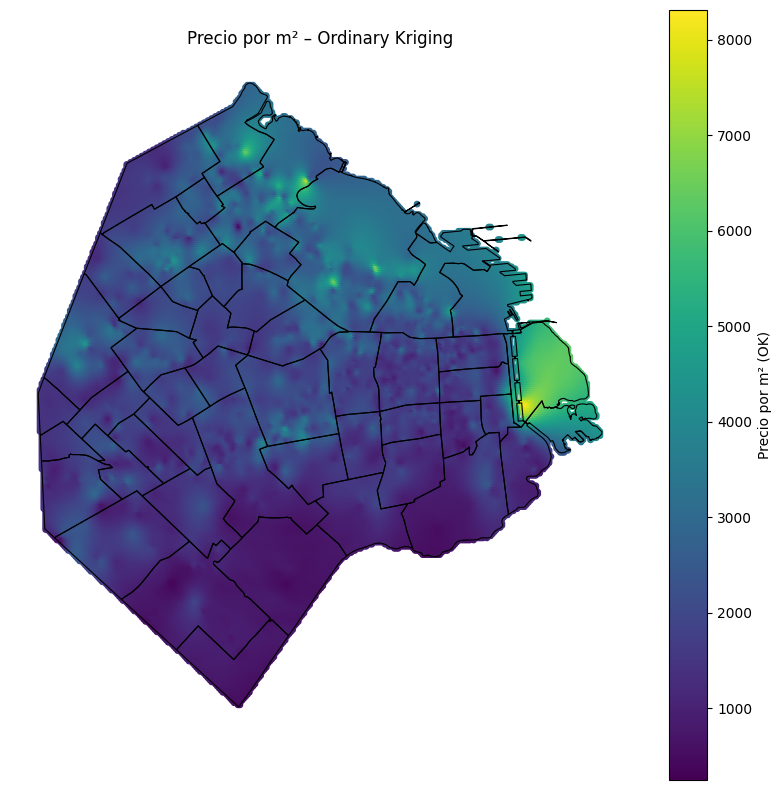

In [9]:



UK = UniversalKriging(
    x,
    y,
    v,
    variogram_model="spherical",
    variogram_parameters={
        "range": range_,
        "sill": sill,
        "nugget": nugget
    },
    drift_terms=["regional_linear"]
)


z, ss = UK.execute(
    'points',
    coords_grid[:, 0],
    coords_grid[:, 1]
)
z = np.ma.filled(z, np.nan)

gdf_grid['precio_m2_ok'] = z

fig, ax = plt.subplots(figsize=(10, 10))

sc = ax.scatter(
    gdf_grid.geometry.x,
    gdf_grid.geometry.y,
    c=gdf_grid['precio_m2_ok'],
    s=15,
)

barrios.boundary.plot(ax=ax, color='black', linewidth=0.8)

plt.colorbar(sc, ax=ax, label='Precio por m² (OK)')
ax.set_title('Precio por m² – Ordinary Kriging')
ax.set_axis_off()
plt.show()


In [14]:
export_path = "../storage/data/arg_venta_caba_processed.csv"
gdf.to_csv(export_path, index=False)